Import all necessary functions

In [1]:
import time

import numpy as np
import torch
from sklearn.metrics import mean_squared_error

import gpplus
from examples.data.data_gen import load_data_buckling_MF
from gpplus.models import GPR
from gpplus.training.eval import evaluate_gp_model
from gpplus.utils import set_seed
from gpplus.utils.latent_reps import get_latent_representations, plot_encoders

This function is used for measuring accuracy of model

In [2]:
def compute_metrics(y_true, y_hat, output_std=None, start_time=None):
    """
    Compute basic metrics for predictions.

    Args:
        y_true: True values (1D array)
        y_hat: Predicted values (1D array)
        output_std: Standard deviation of predictions (optional)
        start_time: Start time for timing (optional)

    Returns:
        dict: Dictionary with computed metrics
    """
    # Convert to numpy if needed
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.detach().cpu().numpy().reshape(-1)
    if isinstance(y_hat, torch.Tensor):
        y_hat = y_hat.detach().cpu().numpy().reshape(-1)
    if output_std is not None and isinstance(output_std, torch.Tensor):
        output_std = output_std.detach().cpu().numpy().reshape(-1)

    # Only add time if start_time is provided
    if start_time is not None:
        metrics = {
            "Time": time.time() - start_time,
            "RRMSE": np.sqrt(mean_squared_error(y_true, y_hat)) / y_true.std(),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
            "MSE": mean_squared_error(y_true, y_hat),
        }
    else:
        metrics = {
            "RRMSE": np.sqrt(mean_squared_error(y_true, y_hat)) / y_true.std(),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
            "MSE": mean_squared_error(y_true, y_hat),
        }

    # Add NIS if output_std is provided
    if output_std is not None:
        z = 1.96
        L = y_hat - z * output_std
        U = y_hat + z * output_std
        width = U - L
        below = (L - y_true) * (y_true < L)
        above = (y_true - U) * (y_true > U)
        interval_score = width + (2 / 0.05) * below + (2 / 0.05) * above
        NIS = interval_score.mean() / y_true.std()
        metrics["NIS"] = NIS
        return metrics

    return metrics

Data generation and standarization. Data in this section is used for both models.

In [3]:
seed = 42
set_seed(seed)

# Generate training and test data for all fidelity levels s0-s3
sources = ["s0", "s1"]
num_train_per_source = {"s0": 250, "s1": 250}
num_test_per_source = {"s0": 5000, "s1": 5000}  # 10k total
# Generate test data
print("\nGenerating test data...")
X_test_data = []
y_test_data = []

data = load_data_buckling_MF(
    n_train=num_train_per_source,
    n_test=num_test_per_source,
    noise_levels=[0.0, 0.0],
    return_one_hot=True,
    shuffle=True,
    seed=seed,
)

# Concatenate all test data (10,000x14)
X_test = data["x_test_full"]
y_test = data["y_test_full"]
# Concatenate all training data (400x14)
X_train = data["x_train_full"]
y_train = data["y_train_full"]

cont_cols = [11]
source_cols = [0, 1]

print(f"\nFinal training dataset shape: X={X_train.shape}, y={y_train.shape}")
print(f"Final test dataset shape: X={X_test.shape}, y={y_test.shape}")


# Standardize the data
scalerX = gpplus.utils.StandardScaler()
scalerX.fit(X_train[:, cont_cols])
X_train[:, cont_cols] = scalerX.transform(X_train[:, cont_cols])
X_test[:, cont_cols] = scalerX.transform(X_test[:, cont_cols])

scalerY = gpplus.utils.StandardScaler()
scalerY.fit(y_train)
y_train = scalerY.transform(y_train)


Generating test data...

Final training dataset shape: X=torch.Size([500, 12]), y=torch.Size([500])
Final test dataset shape: X=torch.Size([10000, 12]), y=torch.Size([10000])


Below is the model setup and training loop for the grouped one-hot encodings

In [4]:
cat_cols = [2, 3, 4, 5, 6, 7, 8, 9, 10]  # Uses a single list for grouped OH encodings
t1 = time.time()

# Create model (omit encoders → MVMFKernel defaults to MatrixEncoder)
kernel = gpplus.kernels.LogScaleKernel(
    gpplus.kernels.MVMFKernel(
        cont_cols=cont_cols,
        cat_cols=cat_cols,
        source_cols=source_cols,
    )
)

model_grouped = GPR(
    X_train,
    y_train,
    kernel_module=kernel,
    mean_module=gpplus.means.MultiMean(source_cols=source_cols),
    likelihood=gpplus.likelihoods.MultiLikelihood(source_cols=source_cols, training_data=X_train),
)

num_inits = 16
print(model_grouped)

# Create trainer
trainer = gpplus.training.GPTrainer(
    model=model_grouped,
    seed=seed,
    num_inits=num_inits,
    stop_conditions=[
        gpplus.training.ConvergencePatienceStopCondition(patience=50),
        gpplus.training.MinLossChangeStopCondition(min_loss_change=1e-7),
    ],
    device="cpu",
)

print("Training model...")
results = trainer.train()

# Evaluate on standardized test data
y_pred_scaled, pred_lower_scaled, pred_upper_scaled, output_std_scaled = evaluate_gp_model(model_grouped, X_test)

# Transform predictions back to original scale for proper metrics
y_pred_orig = scalerY.inverse_transform(y_pred_scaled)
output_std_orig = output_std_scaled * scalerY.std  # Scale the uncertainty

metric = compute_metrics(y_test, y_pred_orig, output_std_orig, start_time=t1)

print("Metrics:")
for k, v in metric.items():
    print(f"  {k}: {v:.4f}")

GPR(
  (likelihood): MultiLikelihood(
    (noise_covar): LogScaleMultiNoise(
      (raw_noise_constraint): SoftClamp(-7, 3, margin=0.01)
    )
  )
  (mean_module): MultiMean(
    (means): ModuleList(
      (0): ZeroMean()
      (1): ConstantMean()
    )
  )
  (covar_module): LogScaleKernel(
    (base_kernel): MVMFKernel(
      (cont_kernel): GaussianKernel(
        (raw_lengthscale_constraint): SoftClamp(-5, 3, margin=0.01)
      )
      (cat_encoder): MatrixEncoder(input_dim=9, z_dim=2)
      (cat_kernel): GaussianKernel(
        (raw_lengthscale_constraint): SoftClamp(-5, 3, margin=0.01)
      )
      (source_kernel): GaussianKernel(
        (raw_lengthscale_constraint): SoftClamp(-5, 3, margin=0.01)
      )
      (source_encoder): MatrixEncoder(input_dim=2, z_dim=2)
    )
    (raw_outputscale_constraint): SoftClamp(-5, 4, margin=0.01)
  )
)
Training model...
Metrics:
  Time: 170.9171
  RRMSE: 0.0037
  RMSE: 265.4790
  MSE: 70479.1235
  NIS: 0.0064


Below shows how to use the latent_reps function to analyze the embeddings

In [5]:
encoder_data_dict = get_latent_representations(model_grouped, qual_dict={0: 2, 1: 4, 2: 3})
print(encoder_data_dict)

{'cat_encoder': {'combinations': tensor([[1, 0, 1, 0, 0, 0, 1, 0, 0],
        [1, 0, 1, 0, 0, 0, 0, 1, 0],
        [1, 0, 1, 0, 0, 0, 0, 0, 1],
        [1, 0, 0, 1, 0, 0, 1, 0, 0],
        [1, 0, 0, 1, 0, 0, 0, 1, 0],
        [1, 0, 0, 1, 0, 0, 0, 0, 1],
        [1, 0, 0, 0, 1, 0, 1, 0, 0],
        [1, 0, 0, 0, 1, 0, 0, 1, 0],
        [1, 0, 0, 0, 1, 0, 0, 0, 1],
        [1, 0, 0, 0, 0, 1, 1, 0, 0],
        [1, 0, 0, 0, 0, 1, 0, 1, 0],
        [1, 0, 0, 0, 0, 1, 0, 0, 1],
        [0, 1, 1, 0, 0, 0, 1, 0, 0],
        [0, 1, 1, 0, 0, 0, 0, 1, 0],
        [0, 1, 1, 0, 0, 0, 0, 0, 1],
        [0, 1, 0, 1, 0, 0, 1, 0, 0],
        [0, 1, 0, 1, 0, 0, 0, 1, 0],
        [0, 1, 0, 1, 0, 0, 0, 0, 1],
        [0, 1, 0, 0, 1, 0, 1, 0, 0],
        [0, 1, 0, 0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0, 0, 0, 1],
        [0, 1, 0, 0, 0, 1, 1, 0, 0],
        [0, 1, 0, 0, 0, 1, 0, 1, 0],
        [0, 1, 0, 0, 0, 1, 0, 0, 1]]), 'indices': tensor([[0, 0, 0],
        [0, 0, 1],
        [0, 0, 2],
        [

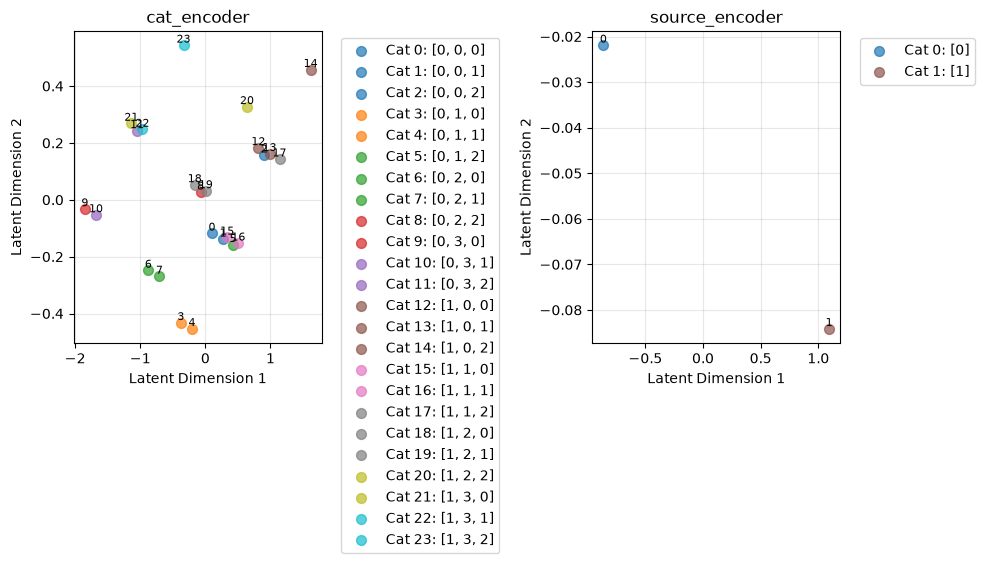

In [6]:
plot_encoders(model_grouped, qual_dict={0: 2, 1: 4, 2: 3})

Below shows the same model using separate OH encodings. This is handled within the combined kernels when a list of lists are passed in.

In [7]:
cat_cols = [[2, 3], [4, 5, 6, 7], [8, 9, 10]]  # Uses lists within lists for separate OH encodings
t1 = time.time()

# Create model (omit encoders → MVMFKernel defaults to MatrixEncoder)
kernel = gpplus.kernels.LogScaleKernel(
    gpplus.kernels.MVMFKernel(
        cont_cols=cont_cols,
        cat_cols=cat_cols,
        source_cols=source_cols,
    )
)

model_separate = GPR(
    X_train,
    y_train,
    kernel_module=kernel,
    mean_module=gpplus.means.MultiMean(source_cols=source_cols),
    likelihood=gpplus.likelihoods.MultiLikelihood(source_cols=source_cols, training_data=X_train),
)

num_inits = 16
print(model_separate)

# Create trainer
trainer = gpplus.training.GPTrainer(
    model=model_separate,
    seed=seed,
    num_inits=num_inits,
    stop_conditions=[
        gpplus.training.ConvergencePatienceStopCondition(patience=50),
        gpplus.training.MinLossChangeStopCondition(min_loss_change=1e-7),
    ],
    device="cpu",
)

print("Training model...")
results = trainer.train()

# Evaluate on standardized test data
y_pred_scaled, pred_lower_scaled, pred_upper_scaled, output_std_scaled = evaluate_gp_model(model_separate, X_test)

# Transform predictions back to original scale for proper metrics
y_pred_orig = scalerY.inverse_transform(y_pred_scaled)
output_std_orig = output_std_scaled * scalerY.std  # Scale the uncertainty

# Compute metrics on original scale
metric = compute_metrics(y_test, y_pred_orig, output_std_orig, start_time=t1)

print("Metrics:")
for k, v in metric.items():
    print(f"  {k}: {v:.4f}")

GPR(
  (likelihood): MultiLikelihood(
    (noise_covar): LogScaleMultiNoise(
      (raw_noise_constraint): SoftClamp(-7, 3, margin=0.01)
    )
  )
  (mean_module): MultiMean(
    (means): ModuleList(
      (0): ZeroMean()
      (1): ConstantMean()
    )
  )
  (covar_module): LogScaleKernel(
    (base_kernel): MVMFKernel(
      (cont_kernel): GaussianKernel(
        (raw_lengthscale_constraint): SoftClamp(-5, 3, margin=0.01)
      )
      (cat_encoder): ModuleList(
        (0): MatrixEncoder(input_dim=2, z_dim=2)
        (1): MatrixEncoder(input_dim=4, z_dim=2)
        (2): MatrixEncoder(input_dim=3, z_dim=2)
      )
      (cat_kernel): GaussianKernel(
        (raw_lengthscale_constraint): SoftClamp(-5, 3, margin=0.01)
      )
      (source_kernel): GaussianKernel(
        (raw_lengthscale_constraint): SoftClamp(-5, 3, margin=0.01)
      )
      (source_encoder): MatrixEncoder(input_dim=2, z_dim=2)
    )
    (raw_outputscale_constraint): SoftClamp(-5, 4, margin=0.01)
  )
)
Training mode

When there is only one variable in each encoder (NOT GROUPED), the latent_reps functions do not need qual_dict passed in

In [8]:
encoder_data_dict = get_latent_representations(model_separate)
print(encoder_data_dict)

{'cat_encoder_0': {'combinations': tensor([[1, 0],
        [0, 1]]), 'indices': tensor([[0],
        [1]]), 'latent_reps': tensor([[-0.2538, -1.8913],
        [ 0.0307,  1.8782]], dtype=torch.float64), 'input_dim': 2}, 'cat_encoder_1': {'combinations': tensor([[1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]]), 'indices': tensor([[0],
        [1],
        [2],
        [3]]), 'latent_reps': tensor([[-2.2248, -0.1173],
        [-0.1776, -0.0092],
        [ 0.7915,  0.0243],
        [ 1.4160,  0.0397]], dtype=torch.float64), 'input_dim': 4}, 'cat_encoder_2': {'combinations': tensor([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]]), 'indices': tensor([[0],
        [1],
        [2]]), 'latent_reps': tensor([[-0.9519,  0.0279],
        [-0.6728,  0.0144],
        [ 1.4642, -0.0882]], dtype=torch.float64), 'input_dim': 3}, 'source_encoder': {'combinations': tensor([[1., 0.],
        [0., 1.]]), 'indices': tensor([[0],
        [1]]), 'latent_reps': tensor([[-0.21

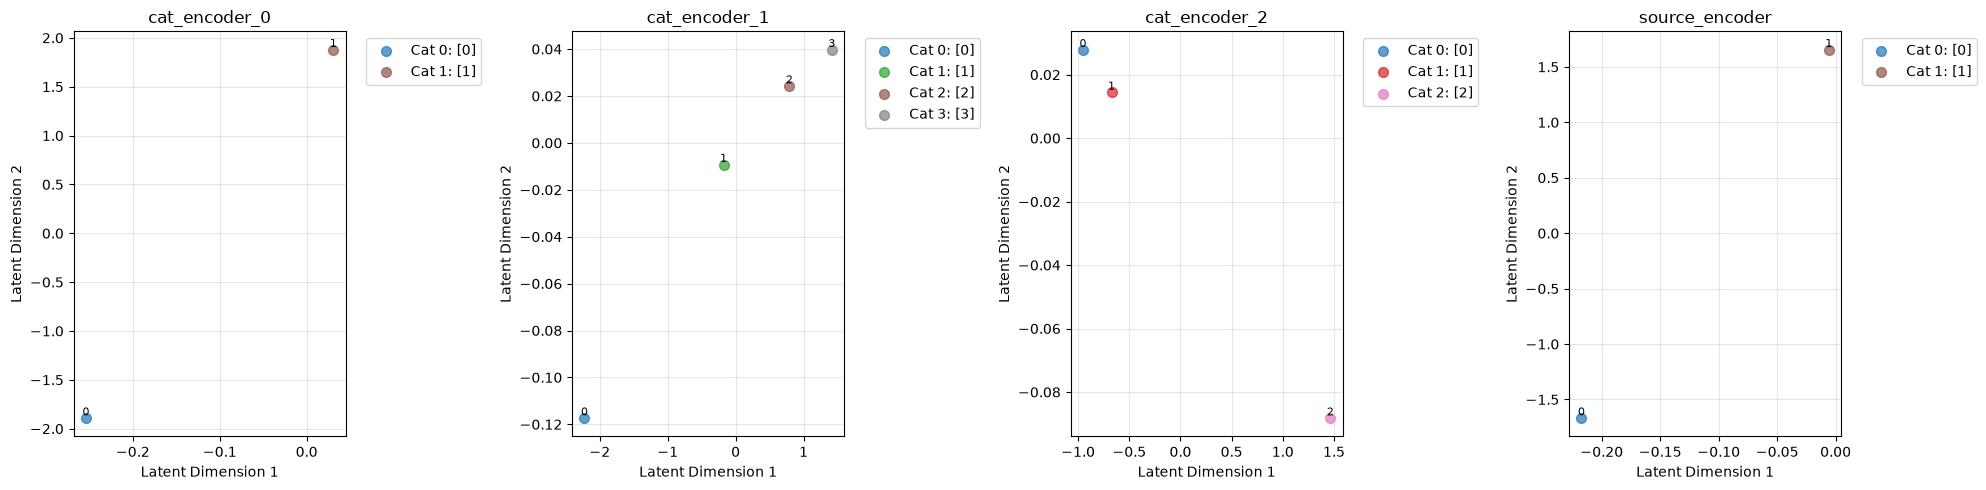

In [9]:
plot_encoders(model_separate)